 # Project: 3 Healthcare & Medical — Chronic Disease Prediction  
 
# 🏥 Week 1: Ethical Data Sourcing, Preprocessing, and Exploration
**Author:** Krishnaveni Mitukula  

**Objective:** Load anonymized EHR dataset, assess missing values, and perform initial statistical exploration.


## DAY 1. Data Loading  & Initial Statistical Summary
Loaded the raw clinical dataset We generate a descriptive summary to understand the distribution, average values, and value ranges of our clinical biomarkers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [7]:
# Load dataset from your raw data folder
df = pd.read_csv('data/raw/heart_disease_data.csv')

# Show the shape of the dataset
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")
df.head()


Dataset Shape: 303 rows and 14 columns


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [8]:
# Display dataset info and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  295 non-null    float64
 4   chol      291 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      298 non-null    object 
 13  target    303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [9]:
# Summary 
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,303.000000,303.000000,303.000000,295.000000,291.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.732203,247.058419,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.546037,52.395183,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,242.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.500000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


## DAY 2: Data Cleaning & Missing Value Assessment

In [10]:
print("\n--- DAY 2: MISSING VALUES & DUPLICATES ---")
# Check for missing values
missing_values = df.isnull().sum()
total_missing = missing_values.sum()
print(f"Total missing values in dataset: {total_missing}")



--- DAY 2: MISSING VALUES & DUPLICATES ---
Total missing values in dataset: 25


In [11]:
# Check and remove duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New dataset shape: {df.shape}")

Number of duplicate rows: 0


In [16]:
# Convert target to binary (0 = No Disease, 1 = Disease) for easier classification later
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print("\nBinary Target Variable Counts (0=Healthy, 1=Disease):")
print(df['target'].value_counts())



Binary Target Variable Counts (0=Healthy, 1=Disease):
target
0    164
1    139
Name: count, dtype: int64


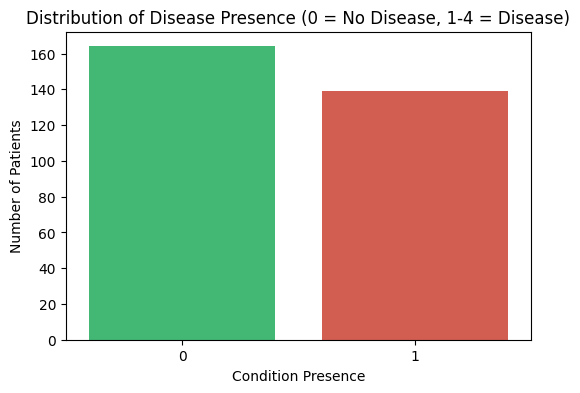

In [17]:
# Target Variable Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette=['#2ECC71', '#E74C3C'])
plt.title('Distribution of Disease Presence (0 = No Disease, 1-4 = Disease)')
plt.xlabel('Condition Presence')
plt.ylabel('Number of Patients')
plt.show()

In [20]:
# 1. Median Imputation for Continuous Clinical Variables
df['chol'] = df['chol'].fillna(df['chol'].median())
df['trestbps'] = df['trestbps'].fillna(df['trestbps'].median())
# 2. Mode Imputation for Categorical Variables
most_frequent_thal = df['thal'].mode()[0]
df['thal'] = df['thal'].fillna(most_frequent_thal)
# Check if they are successfully filled
print("Missing values after imputation:")
print(df.isnull().sum())
print("All missing values successfully handled!")

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
All missing values successfully handled!


## DAY 3: Data Type Conversion & Clinical Outlier Analysis
1. **Type Conversion:** Converted clinical features (like gender and chest pain) into true `categorical` data types for Machine Learning compatibility.
2. **Visualizing Outliers:** Used Boxplots to visually identify patients with extreme medical conditions (e.g., severe hypertension).
3. **Statistical Detection:** Mathematically counted the exact number of extreme patient outliers using the Interquartile Range (IQR) method.

In [21]:
# Convert medical categorical variables from integers to true 'category' types
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in categorical_cols:
    df[col] = df[col].astype('category')
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
print("Data Types after conversion:")
print(df.dtypes)

Data Types after conversion:
age          float64
sex         category
cp          category
trestbps     float64
chol         float64
fbs         category
restecg     category
thalach      float64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
target         int64
dtype: object


In [24]:
# Outlier Analysis (IQR Method)
print("Outlier counts based on IQR Method:\n")
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} patients outside normal bounds.")

Outlier counts based on IQR Method:

age: 0 patients outside normal bounds.
trestbps: 8 patients outside normal bounds.
chol: 5 patients outside normal bounds.
thalach: 1 patients outside normal bounds.
oldpeak: 5 patients outside normal bounds.


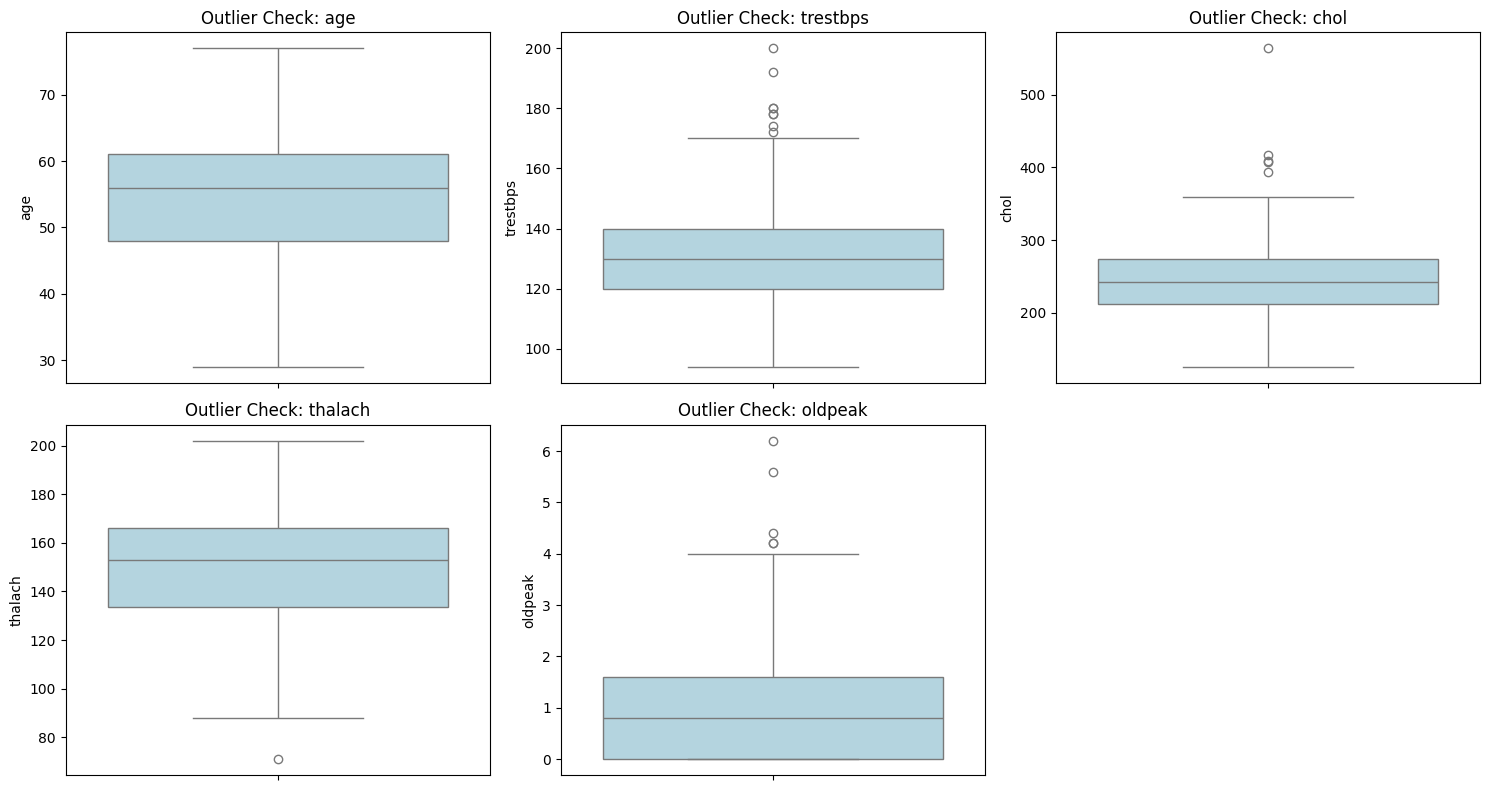

In [25]:
# Visualize Outliers with Boxplots for continuous clinical data
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(f'Outlier Check: {col}')
fig.delaxes(axes[5]) # Remove the 6th empty subplot
plt.tight_layout()
plt.show()